# Modeling Fluid Dynamics of Oxidized 3,3',5,5' Tetramethylbenzidine $\mathrm{TMB_{OX}}$ in a Microfluidic Biosensor
## Appendix B: Codes
### Athena Antippas, Middlebury College Department of Mathematics

Figures 5 - 13 were generated in Python. Below are the codes to execute each in the order presented in the main text.

## How to Use This Notebook

This notebook is intended to be run **top to bottom** in a single session.
All imports, formatting, global parameters, and solver functions are defined
in the opening sections and are required by the figure cells that follow.
Running figure cells out of order or in isolation may result in `NameError`
or `IndexError` due to undefined variables or functions.

> **Note:** Figures 9 and 10 (heatmaps) temporarily use a coarser spatial
> grid (`Nx = 150`) and a simplified sensing radius (`L_sens_mid ~ 0.2406 cm`) for
> computational efficiency and to visualize the overarching trends. The full-resolution grid (`Nx = 300`) is restored
> before Figure 12. All other figures use the parameters defined in the
> Global Parameters section.

Figures can optionally be saved as PDFs by uncommenting the
`plt.savefig(...)` line at the end of each figure's cell.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from scipy import integrate, special
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import itertools
import matplotlib.lines as mlines

## Formatting

In [2]:
# Color Palette
RahnLab_palette = [
    "#2B3A67",  # [0] Delft Blue
    "#33466E",  # [1] YInMn Blue
    "#3A5274",  # [2] YInMn Blue (lighter)
    "#496A81",  # [3] Payne's gray
    "#66999B",  # [4] Moonstone
    "#8DA495",  # [5] Cambridge blue
    "#B3AF8F",  # [6] Sage
    "#D9BA89",  # [7] Ecru
    "#ECBF86",  # [8] Buff
    "#FFC482",  # [9] Peach
]

# "Default" Figure Format
plt.rcParams.update({
    'axes.labelsize':  15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.titlesize':  16,
    'legend.fontsize': 11,
    'legend.frameon':  False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.grid':       False,
})

## Global Parameters

In [3]:
# --- Device & assay constants (Tables 1 & 2) ---
a      = 0.2          # cm     electrode half-width
w      = 0.8          # cm     channel width
h      = 0.0216       # cm     channel height
A      = w * h        # cm²    cross-sectional area
Vm     = 1.80e-7      # mol/(cm³·s)  max reaction rate
Km     = 0.434        # mol/cm³      Michaelis constant

T1     = 110.0        # s      introduction stage duration
T2     = 120.0        # s      incubation stage duration
t_s    = 110.0        # s      sensing stage duration (100-110 s window)

alpha1 = 2.10e-5      # cm/s   introduction flow velocity

# --- Diffusion & sensing ---
D_low  = 5e-6         # cm²/s
D_high = 1e-5         # cm²/s
D_mid  = (D_low + D_high) / 2

delta_low  = np.sqrt(2 * D_low  * t_s)
delta_high = np.sqrt(2 * D_high * t_s)
delta_mid  = np.sqrt(2 * D_mid  * t_s)

L_sens_low  = a + delta_low
L_sens_high = a + delta_high
L_sens_mid  = a + delta_mid

# --- Substrate concentration ---
s0_low  = 4e-7        # mol/cm³
s0_high = 2e-6        # mol/cm³
s0_mid  = (s0_low + s0_high) / 2

# --- Incubation flow velocity ---
alpha2_low  = alpha1 / 200
alpha2_high = alpha1 / 10
alpha2_mid  = alpha1 / 50

# --- Spatial grid (full resolution) ---
x_lo, x_hi = -0.5, 0.5
Nx         = 300
x_grid     = np.linspace(x_lo, x_hi, Nx)

# --- Depletion parameter ---
c_low  = 55.0         # s   fast depletion
c_high = 110.0        # s   slow depletion
c_mid  = (c_low + c_high) / 2

print("Global parameters set.")

print(f"  D range: [{D_low:.3e}, {D_high:.3e}] cm^2/s")
print(f"  alpha2 range: [{alpha2_low:.3e}, {alpha2_high:.3e}] cm/s")
print(f"  s_0 range: [{s0_low:.3e}, {s0_high:.3e}] mol/cm^3")
print(f"  L_sens range: [{L_sens_low:.4f}, {L_sens_high:.4f}] cm")

Global parameters set.
  D range: [5.000e-06, 1.000e-05] cm^2/s
  alpha2 range: [1.050e-07, 2.100e-06] cm/s
  s_0 range: [4.000e-07, 2.000e-06] mol/cm^3
  L_sens range: [0.2332, 0.2469] cm


## Solver Functions

The following functions implement the analytical solutions derived in
Appendix A. Shared functions are used by both Case 1 and Case 2;
case-specific functions are grouped separately for clarity.

### Shared Functions

In [4]:
def beta_of(s0):
    """Constant Michaelis-Menten rate for Case 1 (steady substrate)."""
    return Vm * s0 / (Km + s0)

def _erf_integrand(theta, x_arr, alpha, D):
    """Core erf integrand for the Duhamel convolution."""
    if theta < 1e-14:
        return np.zeros_like(x_arr)
    sq = np.sqrt(4.0 * D * theta)
    return 0.5 * (special.erf((a - x_arr + alpha * theta) / sq) +
                  special.erf((a + x_arr - alpha * theta) / sq))

def w_homogeneous(x_arr, t_local, alpha2, u_end, D):
    """
    Heat-kernel convolution for the homogeneous incubation response.
    Describes advection and diffusion of the introduction-stage residual.
    """
    if t_local <= 1e-14:
        return u_end.copy()
    shifted = x_arr[:, None] - alpha2 * t_local - x_grid[None, :]
    kernel  = (np.exp(-shifted**2 / (4.0 * D * t_local))
               / np.sqrt(4.0 * np.pi * D * t_local))
    return np.trapezoid(kernel * u_end[None, :], x_grid, axis=1)

print("Shared solver functions defined.")

Shared solver functions defined.


### Case 1 (Localized Steady Substrate) Functions

In [8]:
def u_stage(x_arr, t, alpha, beta, D):
    """
    Duhamel/erf solution for a stage with constant production rate beta.
    Used for both the introduction stage and the Case 1 particular solution.
    """
    if t <= 0.0:
        return np.zeros_like(x_arr)
    result, _ = integrate.quad_vec(
        lambda theta: _erf_integrand(theta, x_arr, alpha, D),
        1e-14, t, limit=200, epsabs=1e-14, epsrel=1e-8,
    )
    return beta * result

def u_incubation(x_arr, t_local, alpha2, beta, u_end, D):
    """Full Case 1 incubation solution: particular + homogeneous."""
    return (u_stage(x_arr, t_local, alpha2, beta, D)
            + w_homogeneous(x_arr, t_local, alpha2, u_end, D))

def compute_profiles(s0, alpha2, D, T2, Nt_intro=30, Nt_incub=40):
    """
    Compute concentration profiles over introduction and incubation stages
    for Case 1 (steady substrate).
    Returns t_global, U_all (N_times x Nx), u_end.
    """
    beta    = beta_of(s0)
    t_intro = np.linspace(0.0, T1, Nt_intro)
    U_intro = np.array([u_stage(x_grid, t, alpha1, beta, D) for t in t_intro])
    u_end   = U_intro[-1]

    t_incub_loc = np.linspace(0.0, T2, Nt_incub)
    U_incub = np.array([
        u_incubation(x_grid, t_loc, alpha2, beta, u_end, D)
        for t_loc in t_incub_loc
    ])

    t_global = np.concatenate([t_intro, T1 + t_incub_loc[1:]])
    U_all    = np.concatenate([U_intro, U_incub[1:]], axis=0)
    return t_global, U_all, u_end

# --- Case 1 signal solver ---
def compute_signal_c1(s0, alpha2, D, T2, Nt_intro=40, Nt_incub=100):
    """
    S(t) = integral of u over [-delta, delta] for Case 1 (constant beta).
    """
    beta = beta_of(s0)   # existing Case 1 helper

    t_intro = np.linspace(0.0, T1, Nt_intro)
    U_intro = np.array([u_stage(x_grid, t, alpha1, beta, D)
                        for t in t_intro])
    u_end = U_intro[-1]

    t_incub_loc = np.linspace(0.0, T2, Nt_incub)
    U_incub = np.array([
        u_incubation(x_grid, t_loc, alpha2, beta, u_end, D)
        for t_loc in t_incub_loc
    ])

    t_global = np.concatenate([t_intro, T1 + t_incub_loc[1:]])
    U_all    = np.concatenate([U_intro, U_incub[1:]], axis=0)

    mask = (x_grid >= -L_sens_mid) & (x_grid <= L_sens_mid)
    S = np.array([np.trapezoid(row[mask], x_grid[mask]) for row in U_all])
    return t_global, S

print("Case 1 solver functions defined.")

Case 1 solver functions defined.


### Heatmap Functions

In [6]:
def u_intro(x_arr, t, alpha, beta, D):
    """Introduction-stage solution u(x, t)."""
    if t <= 0.0:
        return np.zeros_like(x_arr)
    result, _ = integrate.quad_vec(
        lambda theta: _erf_integrand(theta, x_arr, alpha, D),
        1e-14, t, limit=200, epsabs=1e-14, epsrel=1e-8)
    return beta * result

def p_hat(x_arr, t_hat, alpha2, beta, D):
    """Particular incubation solution p̂(x, t̂)."""
    if t_hat <= 0.0:
        return np.zeros_like(x_arr)
    result, _ = integrate.quad_vec(
        lambda theta: _erf_integrand(theta, x_arr, alpha2, D),
        1e-14, t_hat, limit=200, epsabs=1e-14, epsrel=1e-8)
    return beta * result

def w_hat(x_arr, t_hat, alpha2, u_end, D):
    """Homogeneous incubation solution ŵ(x, t̂)."""
    if t_hat <= 1e-14:
        return u_end.copy()
    shifted = x_arr[:, None] - alpha2 * t_hat - x_grid[None, :]
    kernel  = (np.exp(-shifted**2 / (4.0 * D * t_hat))
               / np.sqrt(4.0 * np.pi * D * t_hat))
    return np.trapezoid(kernel * u_end[None, :], x_grid, axis=1)

def u_hat(x_arr, t_hat, alpha2, beta, u_end, D):
    """Full incubation solution û(x, t̂) = p̂ + ŵ."""
    return p_hat(x_arr, t_hat, alpha2, beta, D) + w_hat(x_arr, t_hat, alpha2, u_end, D)

def signal_proxy(u_x):
    """S = ∫_{|x|≤L_sens} u dx."""
    return np.trapezoid(u_x[sens_mask], x_grid[sens_mask])

def compute_S(s0, alpha2, D):
    """Compute signal proxy S(T̂) for given (s0, alpha2, D)."""
    beta  = beta_of(s0)
    u_end = u_intro(x_grid, T1, alpha1, beta, D)
    u_h   = u_hat(x_grid, T2, alpha2, beta, u_end, D)
    return signal_proxy(u_h)
    
print("Heatmap solver functions defined.")

Heatmap solver functions defined.


### Case 2 (Parabolic Substrate) Functions

In [7]:
# --- Time-varying β(t) for Case 2 ---
def beta_of_t(t_global, s0, c):
    """
    β(t) = Vm * s(t) / (Km + s(t)),  where
    s(t) = s0 * (1 - ((t - T1)/c)^2)  for t <= T1 + c, else 0.
    t_global is the *global* clock time (0 at start of introduction).
    """
    s = s0 * (1.0 - ((t_global - T1) / c) ** 2)
    s = np.maximum(s, 0.0)   # clamp negative values (past depletion)
    return Vm * s / (Km + s)

# --- Introduction stage (Case 2) ---
def u_stage_c2(x_arr, t, alpha, s0, c, D):
    """
    Duhamel solution for introduction stage (Case 2).
    β(t - θ) evaluated at global time (t - θ) which is in [0, T1].
    """
    if t <= 0.0:
        return np.zeros_like(x_arr)
    def integrand(theta):
        # global time at which source acts = t - theta  (theta = t - tau)
        b = beta_of_t(t - theta, s0, c)
        return b * _erf_integrand(theta, x_arr, alpha, D)
    result, _ = integrate.quad_vec(
        integrand, 1e-14, t, limit=300, epsabs=1e-14, epsrel=1e-8,
    )
    return result

# --- Incubation stage particular solution (Case 2) ---
def p_incub_c2(x_arr, hat_t, alpha2, s0, c, D):
    """
    Particular solution p(x, hat_t) for incubation stage (Case 2).
    Upper limit capped at min(hat_t, c) because β=0 once substrate exhausted.
    β evaluated at hat_t - θ + T1  (global time during incubation).
    """
    if hat_t <= 0.0:
        return np.zeros_like(x_arr)
    t_upper = min(hat_t, c)
    def integrand(theta):
        t_global = hat_t - theta + T1
        b = beta_of_t(t_global, s0, c)
        return b * _erf_integrand(theta, x_arr, alpha2, D)
    result, _ = integrate.quad_vec(
        integrand, 1e-14, t_upper, limit=300, epsabs=1e-14, epsrel=1e-8,
    )
    return result

# --- Full incubation solution ---
def u_incubation_c2(x_arr, hat_t, alpha2, s0, c, u_end, D):
    return (p_incub_c2(x_arr, hat_t, alpha2, s0, c, D)
            + w_homogeneous(x_arr, hat_t, alpha2, u_end, D))

# --- Driver: compute all profiles ---
def compute_profiles_c2(s0, c, alpha2, D, T2, Nt_intro=30, Nt_incub=40):
    """
    Returns:
      t_global  — time array (length Nt_intro + Nt_incub - 1)
      U_all     — (N_times, Nx) concentration fields
      u_end     — spatial profile at end of introduction stage
    """
    t_intro = np.linspace(0.0, T1, Nt_intro)
    U_intro = np.array([u_stage_c2(x_grid, t, alpha1, s0, c, D)
                        for t in t_intro])
    u_end = U_intro[-1]

    t_incub_loc = np.linspace(0.0, T2, Nt_incub)
    U_incub = np.array([
        u_incubation_c2(x_grid, t_loc, alpha2, s0, c, u_end, D)
        for t_loc in t_incub_loc
    ])

    t_global = np.concatenate([t_intro, T1 + t_incub_loc[1:]])
    U_all    = np.concatenate([U_intro, U_incub[1:]], axis=0)
    return t_global, U_all, u_end

# --- Case 2 signal solver ---
def compute_signal_c2(s0, c, alpha2, D, T2, Nt_intro=40, Nt_incub=100):
    t_intro = np.linspace(0.0, T1, Nt_intro)
    U_intro = np.array([u_stage_c2(x_grid, t, alpha1, s0, c, D)
                        for t in t_intro])
    u_end = U_intro[-1]

    t_incub_loc = np.linspace(0.0, T2, Nt_incub)
    U_incub = np.array([
        u_incubation_c2(x_grid, t_loc, alpha2, s0, c, u_end, D)
        for t_loc in t_incub_loc
    ])

    t_global = np.concatenate([t_intro, T1 + t_incub_loc[1:]])
    U_all    = np.concatenate([U_intro, U_incub[1:]], axis=0)

    local_sens_mask = np.abs(x_grid) <= L_sens_mid

    S = np.array([
        np.trapezoid(U_all[i][local_sens_mask], x_grid[local_sens_mask])
        for i in range(len(t_global))
    ])

    return t_global, S

print("Case 2 Solver functions defined.")

Case 2 Solver functions defined.


## Figures

### Figure 5. Parabolic Substrate Profiles

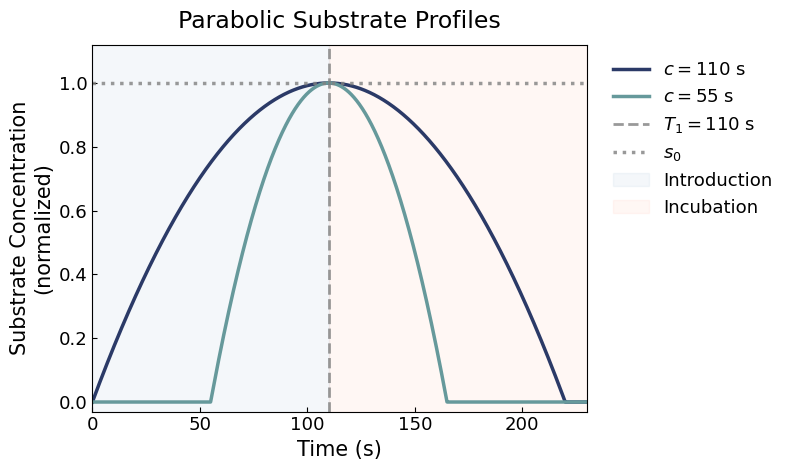

In [8]:
s0   = 1.0     # normalized (plot as fraction of s0)
 
plt.rcParams.update({
    "axes.labelsize":  15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.frameon":  False,
    "xtick.direction": "in",
    "ytick.direction": "in",
})
 
# --- Parabolic substrate profile ---
def s_parab(t, c, s0, T1):
    """
    s(t) = s0 * (1 - ((t - T1)/c)^2)   for t <= T1 + c
           0                             otherwise
    Clipped to [0, s0] so negative values (t < T1 - c) return 0.
    """
    val = s0 * (1.0 - ((t - T1) / c)**2)
    return np.where((t <= T1 + c) & (val >= 0), val, 0.0)
 
configs = [
    dict(c=110, label=r"$c = 110$ s", col=RahnLab_palette[0]),
    dict(c=55, label=r"$c = 55$ s",   col=RahnLab_palette[4]),
]
 
# Time axis: show from t=0 to just past the later depletion time
t_end = max(cfg["c"] for cfg in configs) + T1 + 10
t     = np.linspace(0, t_end, 2000)
 
fig, ax = plt.subplots(figsize=(8, 4.8))
 
for cfg in configs:
    c   = cfg["c"]
    s_t = s_parab(t, c, s0, T1)
    ax.plot(t, s_t, lw=2.5, color=cfg["col"], label=cfg["label"])
 
# Mark T1 (peak / stage boundary)
ax.axvline(T1, color="gray", lw=2, ls="--", alpha=0.8, label=fr"$T_1 = {T1:.0f}$ s")
ax.axhline(1, color = "gray", lw = 2.5, ls=":",alpha = 0.8, label=fr"$s_0$")
 
# Stage shading
ax.axvspan(0,   T1,  alpha=0.06, color="steelblue", label="Introduction")
ax.axvspan(T1, t_end, alpha=0.06, color="coral",    label="Incubation")
 
ax.set_xlim(0, t_end)
ax.set_ylim(-0.03, 1.12)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Substrate Concentration\n(normalized)", fontsize=15)
ax.set_title("Parabolic Substrate Profiles", pad=12, fontsize=17)
fig.subplots_adjust(right=0.75)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=13,
)
 
plt.tight_layout()
# plt.savefig("Parabolic.pdf", bbox_inches='tight') 
plt.savefig("Parabolic.png", bbox_inches='tight') 
plt.show()

### Figure 6. Case 1: Diffusion Strength

In [9]:
# For 6-8, 11:
plt.rcParams.update({
    "figure.figsize":  (6, 5.5),
    "axes.labelsize":  16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.titlesize":  17,
    "legend.fontsize": 11,
    "legend.frameon":  False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid":       False,
})


# --- Spatial grid ---
x_lo, x_hi = -0.5, 0.5
Nx         = 300
x_grid     = np.linspace(x_lo, x_hi, Nx)

# --- Incubation-only snapshot times (hat_t values, relative to T1) ---
snap_t_local = [
    0.0,
    0.33 * T2,
    0.67 * T2,
    T2,
]
snap_labels = [
    r"$\hat{t}=0$ s  (end intro)",
    rf"$\hat{{t}}={0.33*T2:.0f}$ s",
    rf"$\hat{{t}}={0.67*T2:.0f}$ s",
    rf"$\hat{{t}}=T_2={T2:.0f}$ s",
]
profile_colors = [RahnLab_palette[i] for i in [0, 3, 6, 9]]

print("Setup complete.")
print(f"  D_mid      = {D_mid:.3e} cm²/s")
print(f"  L_sens_low = {L_sens_low:.4f} cm")
print(f"  L_sens_mid = {L_sens_mid:.4f} cm")
print(f"  L_sens_high= {L_sens_high:.4f} cm")
print(f"  s0_mid     = {s0_mid:.3e} mol/cm³")
print(f"  alpha2_mid = {alpha2_mid:.3e} cm/s  (~alpha1/{alpha1/alpha2_mid:.0f})")

Setup complete.
  D_mid      = 7.500e-06 cm²/s
  L_sens_low = 0.2332 cm
  L_sens_mid = 0.2406 cm
  L_sens_high= 0.2469 cm
  s0_mid     = 1.200e-06 mol/cm³
  alpha2_mid = 4.200e-07 cm/s  (~alpha1/50)


  Done: Low Diffusion
  Done: High Diffusion


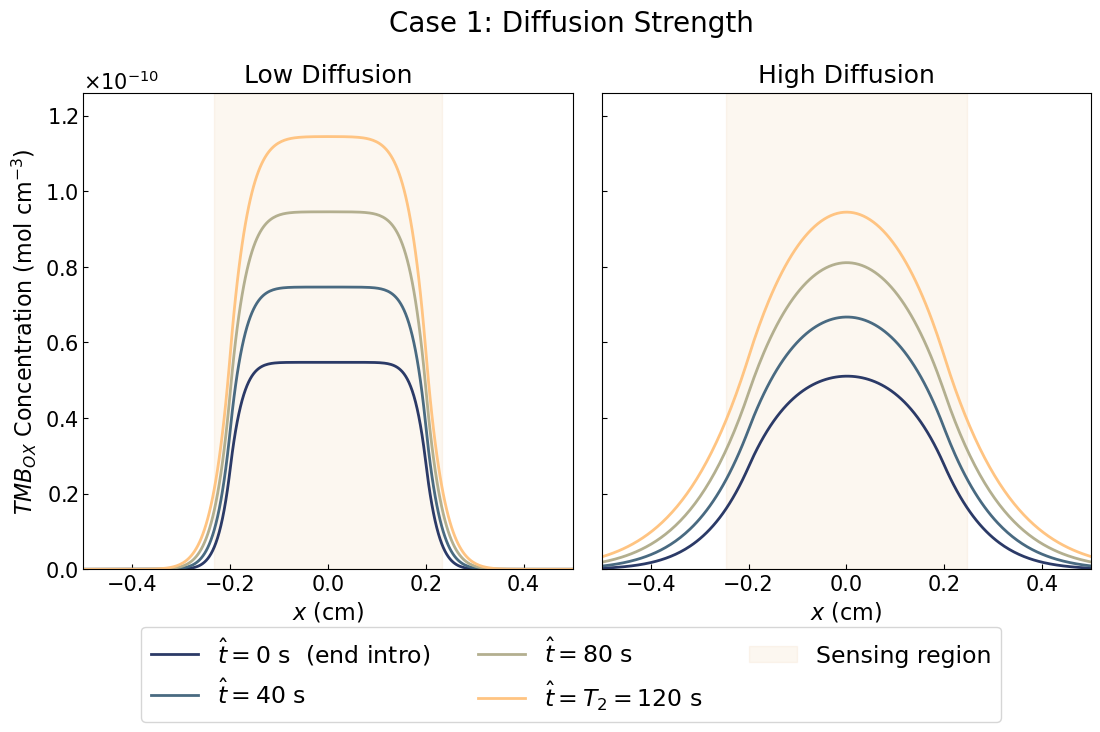

In [10]:
D_superhigh = D_high*10

delta_superhigh = np.sqrt(2 * D_superhigh * t_s)

L_sens_superhigh = a + delta_superhigh

fig1_configs = [
    dict(D=D_mid,  L_sens=L_sens_low,
        # title=fr"D in range,  $R={L_sens_low:.3f}$ cm"),
         title=fr"Low Diffusion"),
    dict(D=D_superhigh, L_sens=L_sens_high,
         #title=fr"D exceeding range,  $R={L_sens_superhigh:.3f}$ cm"),
         title=fr"High Diffusion"),
]

fig1_data = []
for cfg in fig1_configs:
    t_gl, U, u_end = compute_profiles(s0_mid, alpha2_mid, cfg["D"], T2)
    fig1_data.append((t_gl, U, cfg["title"], cfg["L_sens"]))
    print(f"  Done: {cfg['title']}")

# shared y-axis max (incubation snapshots only)
global_ymax = max(
    np.max(U[np.argmin(np.abs(t_gl - (T1 + tl)))])
    for (t_gl, U, _, _) in fig1_data
    for tl in snap_t_local
) * 1.1
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(13, 7))
fig.subplots_adjust(wspace=0.06, bottom=0.2)

for ax, (t_gl, U, subtitle, L_sens) in zip(axes, fig1_data):
    for t_loc, lbl, col in zip(snap_t_local, snap_labels, profile_colors):
        t_query = T1 + t_loc
        idx = np.argmin(np.abs(t_gl - t_query))
        ax.plot(x_grid, U[idx], color=col, lw=2, label=lbl)

    ax.axvspan(-L_sens, L_sens, alpha=0.12, color=RahnLab_palette[8],
               zorder=0, label=fr"Sensing region")

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0, global_ymax)
    ax.set_xlabel("$x$ (cm)")
    ax.set_title(subtitle, fontsize=18, pad=8)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

axes[0].set_ylabel("$TMB_{OX}$ Concentration (mol cm$^{-3}$)")
axes[1].tick_params(labelleft=False)

handles, labels = axes[0].get_legend_handles_labels()

# Place legend below graphs
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.035),
           ncol=3,  
           fontsize=17, frameon=True)

fig.suptitle(
    fr"Case 1: Diffusion Strength",
    fontsize=20, y=1,
)

# plt.savefig("Case1Diff.pdf", bbox_inches='tight')
plt.savefig("Case1Diff.png", bbox_inches='tight')
plt.show()

### Figure 7. Case 1: Incubation Stage Advection Strength

  Done: Slow Advection
  Done: Fast Advection


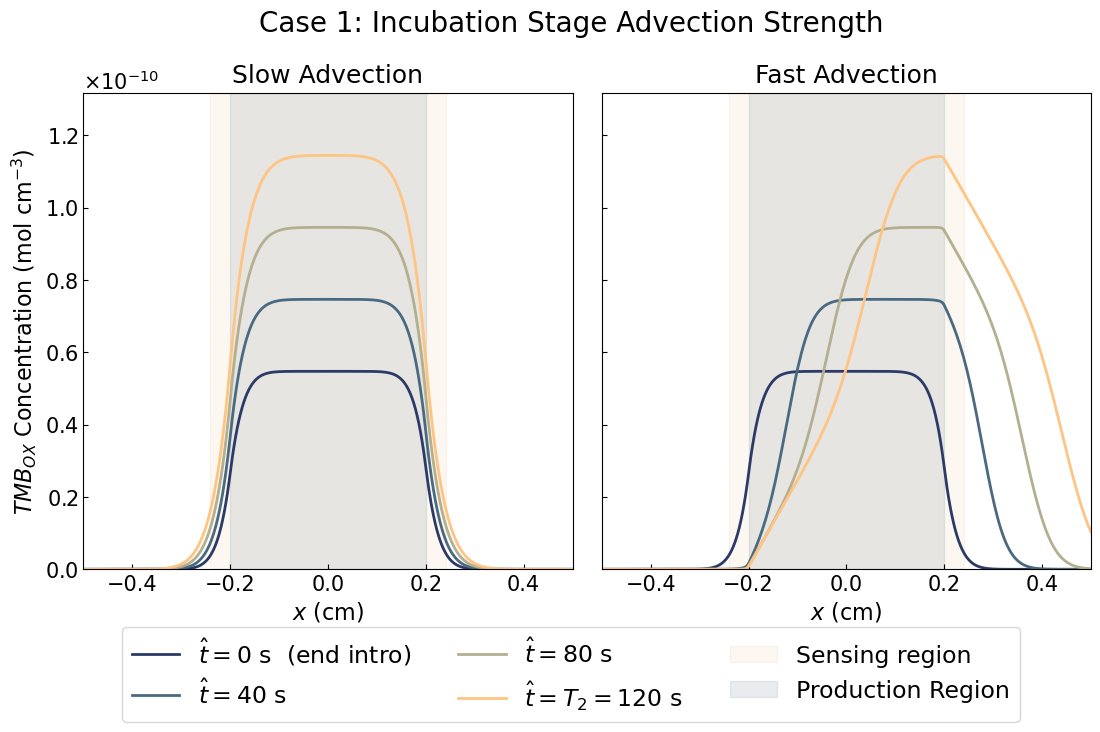

In [11]:
alpha2_extreme = alpha1 * 100  # extreme value for visualization only

fig2_configs = [
    dict(alpha2=alpha2_mid,
         title=fr"Slow Advection"),
    dict(alpha2=alpha2_extreme,
         title=fr"Fast Advection"),
]

fig2_data = []
for cfg in fig2_configs:
    t_gl, U, u_end = compute_profiles(s0_mid, cfg["alpha2"], D_mid, T2)
    fig2_data.append((t_gl, U, cfg["title"]))
    print(f"  Done: {cfg['title']}")

global_ymax = max(
    np.max(U[np.argmin(np.abs(t_gl - (T1 + tl)))])
    for (t_gl, U, _) in fig2_data
    for tl in snap_t_local
) * 1.15

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(13, 7))
fig.subplots_adjust(wspace=0.06, bottom=0.2)

for ax, (t_gl, U, subtitle) in zip(axes, fig2_data):
    for t_loc, lbl, col in zip(snap_t_local, snap_labels, profile_colors):
        idx = np.argmin(np.abs(t_gl - (T1 + t_loc)))
        ax.plot(x_grid, U[idx], color=col, lw=2, label=lbl)

    ax.axvspan(-L_sens_mid, L_sens_mid, alpha=0.12, color=RahnLab_palette[8],
               zorder=0, label=fr"Sensing region")

    ax.axvspan(-a, a, alpha=0.12, color=RahnLab_palette[3],
               zorder=0, label=fr"Production Region")

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0, global_ymax)
    ax.set_xlabel("$x$ (cm)")
    ax.set_title(subtitle, fontsize=18, pad=8)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

axes[0].set_ylabel("$TMB_{OX}$ Concentration (mol cm$^{-3}$)")
axes[1].tick_params(labelleft=False)

handles, labels = axes[0].get_legend_handles_labels()

# Place legend below graphs
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.035),
           ncol=3,   
           fontsize=17, frameon=True)

fig.suptitle(
    fr"Case 1: Incubation Stage Advection Strength",
    fontsize=20, y=1.0,
)

# plt.savefig("Case1Adv.pdf", bbox_inches='tight') 
plt.savefig("Case1Adv.png", bbox_inches='tight') 
plt.show()

### Figure 8. Case 1: Substrate Availability

  Done: Low Substrate 
Concentration
  Done: High Substrate 
Concentration


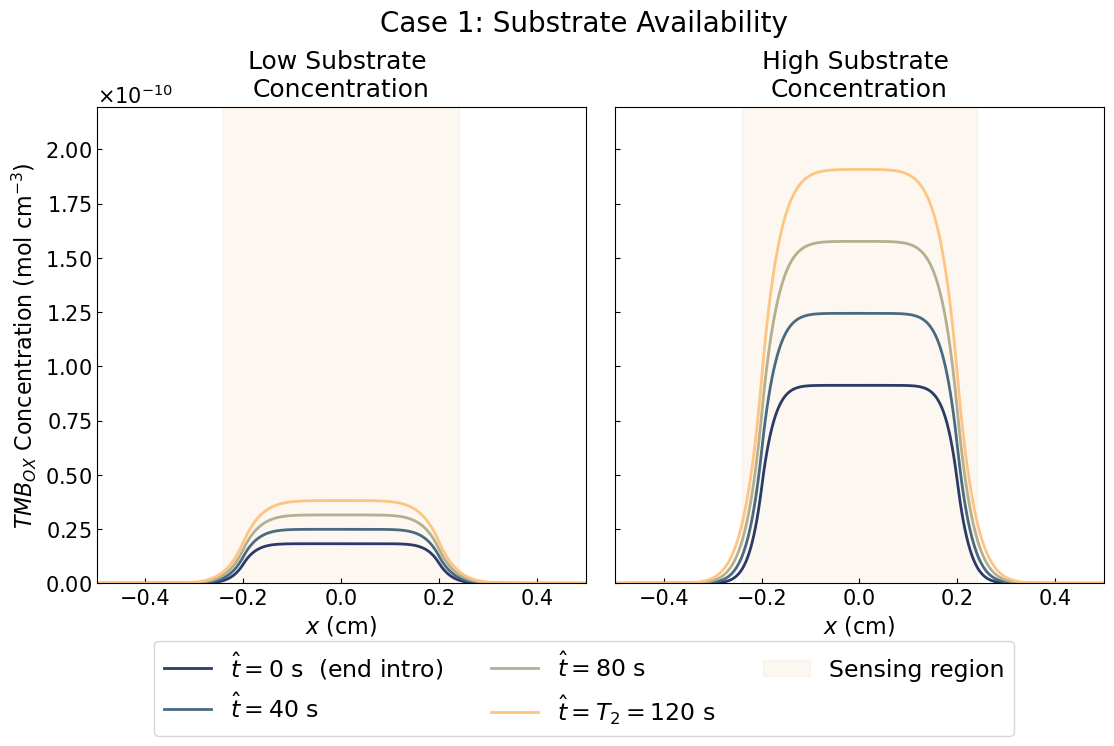

In [12]:
fig3_configs = [
    dict(s0=s0_low,
         title="Low Substrate \nConcentration"),
    dict(s0=s0_high,
         title="High Substrate \nConcentration"),
]

fig3_data = []
for cfg in fig3_configs:
    t_gl, U, u_end = compute_profiles(cfg["s0"], alpha2_mid, D_mid, T2)
    fig3_data.append((t_gl, U, cfg["title"]))
    print(f"  Done: {cfg['title']}")

global_ymax = max(
    np.max(U[np.argmin(np.abs(t_gl - (T1 + tl)))])
    for (t_gl, U, _) in fig3_data
    for tl in snap_t_local
) * 1.15

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(13, 7))
fig.subplots_adjust(wspace=0.06, bottom=0.2)

for ax, (t_gl, U, subtitle) in zip(axes, fig3_data):
    for t_loc, lbl, col in zip(snap_t_local, snap_labels, profile_colors):
        idx = np.argmin(np.abs(t_gl - (T1 + t_loc)))
        ax.plot(x_grid, U[idx], color=col, lw=2, label=lbl)

    ax.axvspan(-L_sens_mid, L_sens_mid, alpha=0.12, color=RahnLab_palette[8],
               zorder=0, label=fr"Sensing region")

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0, global_ymax)
    ax.set_xlabel("$x$ (cm)")
    ax.set_title(subtitle, fontsize=18, pad=8)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

axes[0].set_ylabel("$TMB_{OX}$ Concentration (mol cm$^{-3}$)")
axes[1].tick_params(labelleft=False)

handles, labels = axes[0].get_legend_handles_labels()

# Place legend below graphs
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.035),
           ncol=3,  
           fontsize=17, frameon=True)

fig.suptitle(
    fr"Case 1: Substrate Availability",
    fontsize=20, y=1.02,
)

# plt.savefig("Case1Subst.pdf", bbox_inches='tight') 
plt.savefig("Case1Subst.png", bbox_inches='tight') 
plt.show()

### Figure 9. Signal Proxy $S(\hat{t})$ on ($D$, $\alpha_2 / \alpha_1$) Plane

In [13]:
# For Figures 9 & 10
plt.rcParams.update({
    'figure.figsize':  (7, 6),
    'axes.labelsize':  15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.titlesize':  16,
    'legend.fontsize': 11,
    'legend.frameon':  False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.grid':       False,
})

In [14]:
# Reduced resolution grid for heatmap performance
x_lo, x_hi = -0.5, 0.5
Nx        = 150  # reduced from 300 for heatmap performance
x_grid    = np.linspace(x_lo, x_hi, Nx)
sens_mask = np.abs(x_grid) <= L_sens_mid # independent sensing radius for heatmap visualization (general trends still observed)

  D row 5/28 done
  D row 10/28 done
  D row 15/28 done
  D row 20/28 done
  D row 25/28 done
  Plot 1 saved.


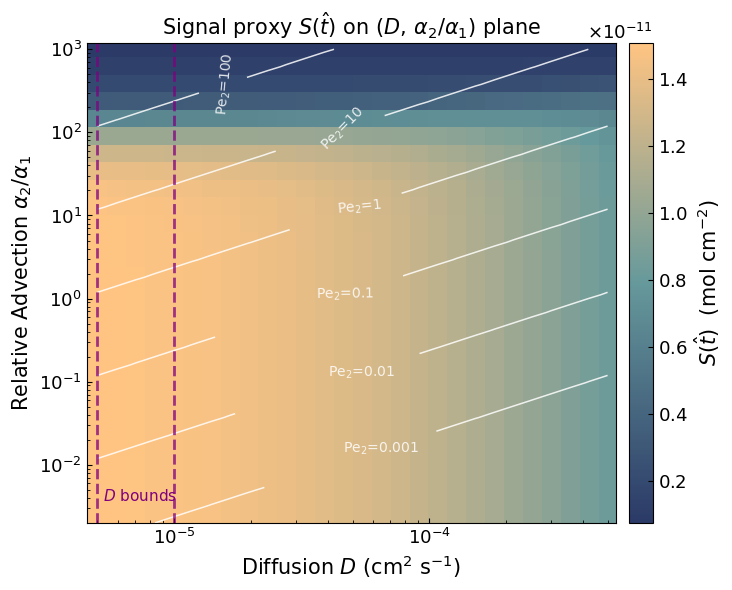

In [15]:
N1    = 28
# α₂ range: well below α₁ (constraint α₂ ≪ α₁)
alpha2_vals = np.logspace(np.log10(alpha1 / 500), np.log10(alpha1 * 1000), N1)
# D range: from table 1 min to beyond max to show different regimes
D_vals      = np.logspace(np.log10(5e-6), np.log10(5e-4), N1)

S_grid1 = np.zeros((N1, N1))
for i, D_v in enumerate(D_vals):
    for j, a2 in enumerate(alpha2_vals):
        S_grid1[i, j] = compute_S(4e-7, a2, D_v)   # s0 fixed at lower bound
    if (i+1) % 5 == 0:
        print(f"  D row {i+1}/{N1} done")

# Pe₂ = α₂ * a / D on the (D, α₂/α₁) meshgrid
# S_grid1[i,j] = S(D_vals[i], alpha2_vals[j])
# pcolormesh(x, y, Z): x=D (cols), y=α₂/α₁ (rows) → need S_grid1.T
D_mg, A2_mg = np.meshgrid(D_vals, alpha2_vals / alpha1)
Pe2_grid    = A2_mg * alpha1 * a / D_mg
Pe_levels   = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Colormap
cmap1 = mcolors.LinearSegmentedColormap.from_list(
    "RahnLab", [RahnLab_palette[0], RahnLab_palette[4], RahnLab_palette[9]])

fig1, ax1 = plt.subplots(figsize=(7.5, 6))
pcm = ax1.pcolormesh(D_vals, alpha2_vals / alpha1, S_grid1.T,
                     cmap=cmap1, shading='auto')
cb = fig1.colorbar(pcm, ax=ax1, pad=0.02)
cb.set_label(r"$S(\hat{t})$  (mol cm$^{-2}$)", fontsize=15)
cb.formatter = ticker.ScalarFormatter(useMathText=True)
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()

# Pe level curves
cs = ax1.contour(D_vals, alpha2_vals / alpha1, Pe2_grid,
                 levels=Pe_levels, colors='white', linewidths=1.1, alpha=0.85)
ax1.clabel(cs, fmt=lambda v: f"Pe$_2$={v:g}", fontsize=10, inline=True, inline_spacing=0)

# Mark literature D bounds
ax1.axvline(5e-6, color='purple', lw=2, ls='--', alpha=0.75)
ax1.axvline(1e-5, color='purple', lw=2, ls='--', alpha=0.75)
ax1.text(0.03, 0.04, r"$D$ bounds", color='purple', fontsize=11,
         transform=ax1.transAxes, va='bottom')

ax1.set_xlabel(r"Diffusion $D$ (cm$^2$ s$^{-1}$)")
ax1.set_ylabel(r"Relative Advection $\alpha_2 / \alpha_1$")
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title(r"Signal proxy $S(\hat{t})$ on $(D,\, \alpha_2/\alpha_1)$ plane", fontsize=15)
plt.tight_layout()
#plt.savefig("heatmap1_alpha2_D.pdf", bbox_inches='tight')
plt.savefig("heatmap1_alpha2_D.png", bbox_inches='tight')
print("  Plot 1 saved.")

### Figure 10. Signal Proxy $S(\hat{t})$ on ($Pe_2$, $s_0$) Plane
_Note: "$Pe_1$ Bounds" label outputs in a different spot on python figure preview than the PDF; label position was optimized for PDF version_

  Pe row 5/28 done
  Pe row 10/28 done
  Pe row 15/28 done
  Pe row 20/28 done
  Pe row 25/28 done
  Plot 2 saved.
Done!


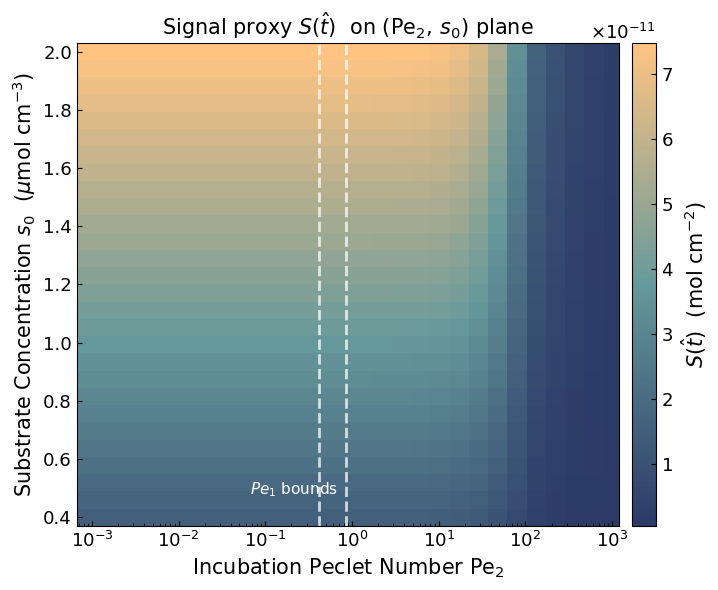

In [16]:
N2     = 28
s0_vals  = np.linspace(4e-7, 2e-6, N2)
# Pe₂ axis: derive α₂ = Pe₂ * D / a, 
Pe2_vals = np.logspace(-3, 3, N2)   # 0.001 → 100
# convert to α₂ for solver
alpha2_from_Pe = Pe2_vals * D_mid / a

S_grid2 = np.zeros((N2, N2))
for i, Pe in enumerate(Pe2_vals):
    a2 = alpha2_from_Pe[i]
    for j, s0 in enumerate(s0_vals):
        S_grid2[i, j] = compute_S(s0, a2, D_mid)
    if (i+1) % 5 == 0:
        print(f"  Pe row {i+1}/{N2} done")

cmap2 = mcolors.LinearSegmentedColormap.from_list(
    "RahnLab2", [RahnLab_palette[0], RahnLab_palette[4], RahnLab_palette[9]])

fig2, ax2 = plt.subplots(figsize=(7.5, 6))
pcm2 = ax2.pcolormesh(Pe2_vals, s0_vals * 1e6, S_grid2.T,
                      cmap=cmap2, shading='auto')
cb2 = fig2.colorbar(pcm2, ax=ax2, pad=0.02)
cb2.set_label(r"$S(\hat{t})$  (mol cm$^{-2}$)", fontsize=15)
cb2.formatter = ticker.ScalarFormatter(useMathText=True)
cb2.formatter.set_powerlimits((0, 0))
cb2.update_ticks()

# Mark literature Pe_1 bounds
ax2.axvline(0.42, color='white', lw=2, ls='--', alpha=0.75)
ax2.axvline(0.84, color='white', lw=2, ls='--', alpha=0.75)
ax2.text(0.3, 0.04, r"$Pe_1$ bounds", color='white', fontsize=11,
         transform=ax1.transAxes, va='bottom')

ax2.set_xlabel(r"Incubation Peclet Number $\mathrm{Pe}_2$")
ax2.set_ylabel(r"Substrate Concentration $s_0$  ($\mu$mol cm$^{-3}$)")
ax2.set_xscale('log')
ax2.set_title(r"Signal proxy $S(\hat{t})$  on $(\mathrm{Pe}_2,\, s_0)$ plane", fontsize=15)
plt.tight_layout()
#plt.savefig("heatmap2_s0_Pe2.pdf", bbox_inches='tight')
plt.savefig("heatmap2_s0_Pe2.png", bbox_inches='tight')
print("  Plot 2 saved.")
print("Done!")

### Figure 11. Case 1: Signal Proxy

Solving Case 1 signal proxy (2 curves, global time 0–300 s)...
  s0 (lower limit)    no peak within 0–300 s (signal still rising)
  s0 (upper limit)    no peak within 0–300 s (signal still rising)


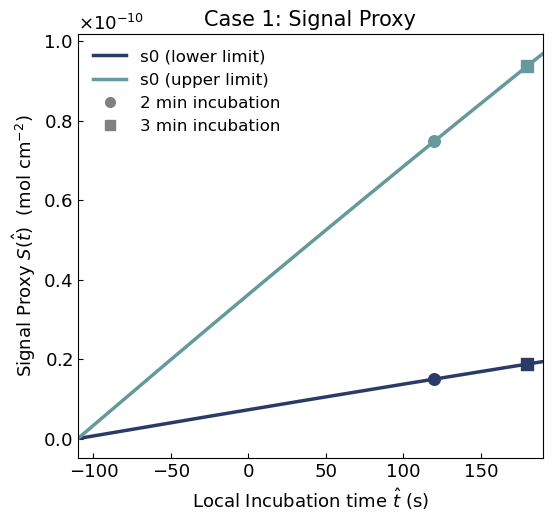

In [10]:
# --- Case 1 signal plot ---
# Reset to full-resolution grid after heatmap section
Nx     = 300
x_grid = np.linspace(x_lo, x_hi, Nx)

T2_SIG_C1 = 300.0 - T1

color_map_c1 = {s0_low: RahnLab_palette[0], s0_high: RahnLab_palette[4]}

t_2min = 120.0
t_3min = 180.0

print("Solving Case 1 signal proxy (2 curves, global time 0–300 s)...")

fig, ax = plt.subplots(figsize=(6, 5.5))

for s0 in [s0_low, s0_high]:
    t_gl, S = compute_signal_c1(s0, alpha2_mid, D_mid,
                                 T2=T2_SIG_C1, Nt_intro=40, Nt_incub=100)

    t_hat = t_gl - 110.0   # re-index to local incubation time

    mask   = t_gl <= 300.0
    t_plot = t_hat[mask]
    S_plot = S[mask]

    lbl = "s0 (lower limit)" if s0 == s0_low else "s0 (upper limit)"
    ax.plot(t_plot, S_plot,
            color=color_map_c1[s0], lw=2.5, label=lbl)

    # --- Peak marker ---
    dS = np.diff(S_plot)
    peak_idx = np.where((dS[:-1] > 0) & (dS[1:] <= 0))[0] + 1
    if len(peak_idx) > 0:
        best = peak_idx[np.argmax(S_plot[peak_idx])]
        t_peak = t_plot[best]
        S_peak = S_plot[best]
        ax.scatter(t_peak, S_peak,
                   color=color_map_c1[s0], marker="*", s=180, zorder=7)
        print(f"  {lbl}    peak at hat_t={t_peak:.1f} s")
    else:
        print(f"  {lbl}    no peak within 0–300 s (signal still rising)")

    # --- 2 min and 3 min incubation markers ---
    for t_ref, mk in [(t_2min, "o"), (t_3min, "s")]:
        if t_ref <= t_plot[-1]:
            S_ref = np.interp(t_ref, t_plot, S_plot)
            ax.scatter(t_ref, S_ref,
                       color=color_map_c1[s0], marker=mk, s=70, zorder=6)


ax.set_xlim(-110, 190)
ax.set_xlabel(r"Local Incubation time $\hat{t}$ (s)", fontsize=13)
ax.set_ylabel(r"Signal Proxy $S(\hat{t})$  (mol cm$^{-2}$)", fontsize=13)
ax.set_title(
    "Case 1: Signal Proxy",
    fontsize=15,
)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

shape_legend = [
    #mlines.Line2D([], [], color="gray", marker="*", linestyle="None", #omit if no peaks
             #     markersize=10, label="Peak"),
    mlines.Line2D([], [], color="gray", marker="o", linestyle="None",
                  markersize=7,  label="2 min incubation"),
    mlines.Line2D([], [], color="gray", marker="s", linestyle="None",
                  markersize=7,  label="3 min incubation"),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + shape_legend, labels + [h.get_label() for h in shape_legend],
          loc="upper left", fontsize=12, frameon=False)

# plt.savefig("Case1_signal.pdf", bbox_inches="tight")
plt.savefig("Case1_signal.pdf", bbox_inches="tight")
plt.show()

### Figure 12. Case 2: Depletion Rate $c$

In [18]:
# For Figures 12 & 13
plt.rcParams.update({
    "figure.figsize":  (6, 5.5),
    "axes.labelsize":  16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize":  14,
    "legend.fontsize": 11,
    "legend.frameon":  False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid":       False,
})

# --- Spatial grid ---
x_lo, x_hi = -0.5, 0.5
Nx         = 300
x_grid     = np.linspace(x_lo, x_hi, Nx)

# --- Snapshot times (hat_t relative to T1) ---
snap_t_local = [0.0, 0.33 * T2, 0.67 * T2, T2]
snap_labels  = [
    r"$\hat{t}=0$ s  (end intro)",
    rf"$\hat{{t}}={0.33*T2:.0f}$ s",
    rf"$\hat{{t}}={0.67*T2:.0f}$ s",
    rf"$\hat{{t}}=T_2={T2:.0f}$ s",
]
profile_colors = [RahnLab_palette[i] for i in [0, 3, 6, 9]]

print("Setup complete.")
print(f"  c_low  = {c_low:.1f} s")
print(f"  c_mid  = {c_mid:.1f} s")
print(f"  c_high = {c_high:.1f} s substrate starts at 0, peaks at T1")

Setup complete.
  c_low  = 55.0 s
  c_mid  = 82.5 s
  c_high = 110.0 s substrate starts at 0, peaks at T1


  Done: $c = 55$ s  (fast depletion)
  Done: $c = 110$ s  (slow depletion)


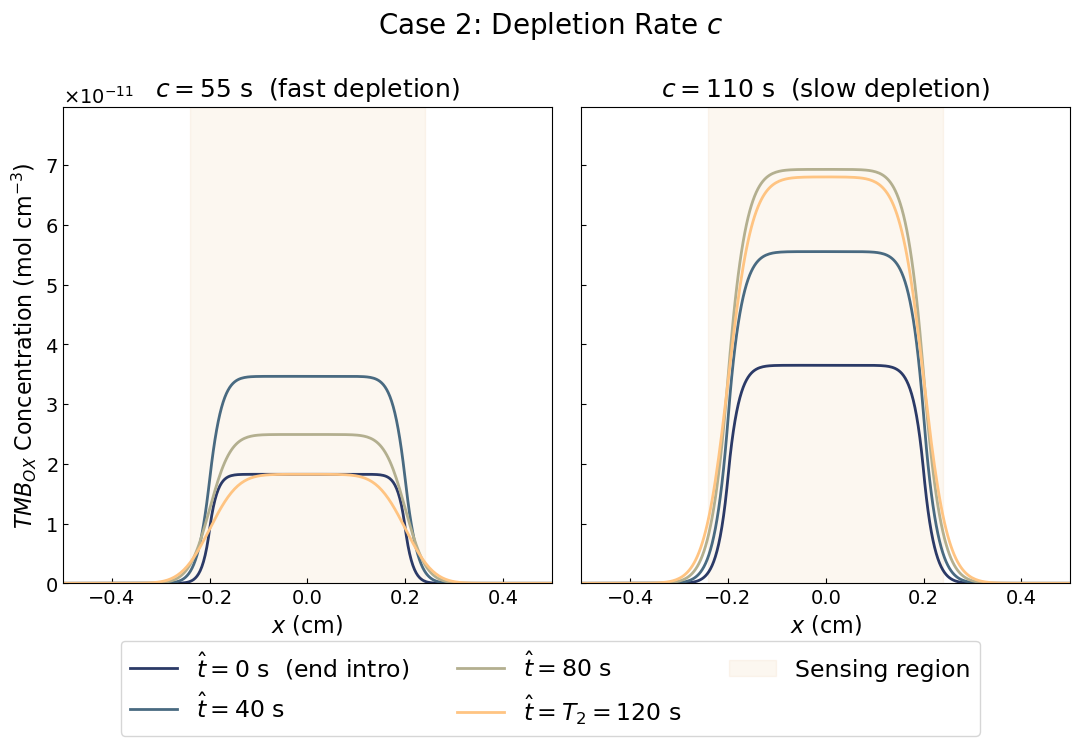

In [19]:
fig2_configs = [
    dict(c=c_low,
         title=fr"$c = {c_low:.0f}$ s  (fast depletion)"),
    dict(c=c_high,
         title=fr"$c = {c_high:.0f}$ s  (slow depletion)"),
]

fig2_data = []
for cfg in fig2_configs:
    t_gl, U, u_end = compute_profiles_c2(s0_mid, cfg["c"],
                                          alpha2_mid, D_mid, T2)
    fig2_data.append((t_gl, U, cfg["title"]))
    print(f"  Done: {cfg['title']}")

global_ymax = max(
    np.max(U[np.argmin(np.abs(t_gl - (T1 + tl)))])
    for (t_gl, U, _) in fig2_data
    for tl in snap_t_local
) * 1.15

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(13, 7))
fig.subplots_adjust(wspace=0.06, bottom=0.2)

for ax, (t_gl, U, subtitle) in zip(axes, fig2_data):
    for t_loc, lbl, col in zip(snap_t_local, snap_labels, profile_colors):
        idx = np.argmin(np.abs(t_gl - (T1 + t_loc)))
        ax.plot(x_grid, U[idx], color=col, lw=2, label=lbl)

    ax.axvspan(-L_sens_mid, L_sens_mid, alpha=0.12, color=RahnLab_palette[8],
               zorder=0, label="Sensing region")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0, global_ymax)
    ax.set_xlabel("$x$ (cm)")
    ax.set_title(subtitle, fontsize=18, pad=8)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

axes[0].set_ylabel("$TMB_{OX}$ Concentration (mol cm$^{-3}$)")
axes[1].tick_params(labelleft=False)

handles, labels = axes[0].get_legend_handles_labels()

# Place legend below graphs
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.035),
           ncol=3,  
           fontsize=17, frameon=True)

fig.suptitle(
    fr"Case 2: Depletion Rate $c$",
    fontsize=20, y=1.02,
)
# plt.savefig("Case2_c.pdf", bbox_inches="tight") 
plt.savefig("Case2_c.png", bbox_inches="tight") 
plt.show()

### Figure 13. Case 2: Signal Proxy

Solving signal proxy (4 curves, global time 0–300 s)...
  s0 (lower limit), c = 55 s    peak at hat_t=53.7 s
  s0 (lower limit), c = 110 s    peak at hat_t=107.5 s
  s0 (upper limit), c = 55 s    peak at hat_t=53.7 s
  s0 (upper limit), c = 110 s    peak at hat_t=107.5 s


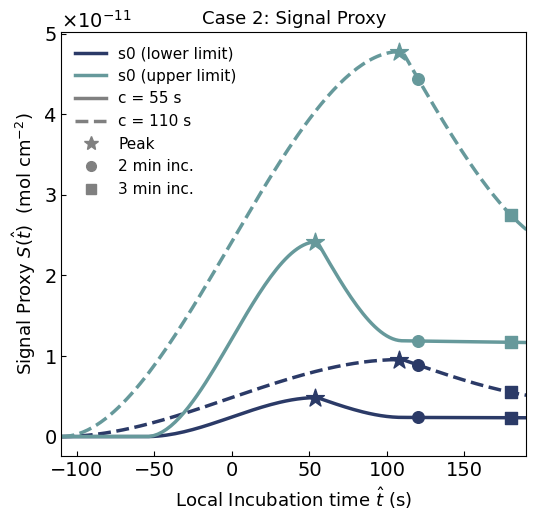

In [20]:
T2_SIG = 300.0 - T1

sig_s0_vals = [s0_low, s0_high]
sig_c_vals  = [c_low,  c_high]

color_map = {s0_low: RahnLab_palette[0], s0_high: RahnLab_palette[4]}
style_map  = {c_low: "-", c_high: "--"}

t_2min = 120.0
t_3min = 180.0

print("Solving signal proxy (4 curves, global time 0–300 s)...")

fig, ax = plt.subplots(figsize=(6, 5.5))

for s0_val, c_val in itertools.product(sig_s0_vals, sig_c_vals):
    t_gl, S = compute_signal_c2(s0_val, c_val, alpha2_mid, D_mid,
                                 T2=T2_SIG, Nt_intro=40, Nt_incub=100)

    t_hat = t_gl - 110.0

    mask   = t_gl <= 300.0
    t_plot = t_hat[mask]
    S_plot = S[mask]

    lbl = "s0 (lower limit)" if s0_val == s0_low else "s0 (upper limit)"
    ax.plot(t_plot, S_plot,
            color=color_map[s0_val], ls=style_map[c_val], lw=2.5, label=lbl)

    # --- Peak marker ---
    dS = np.diff(S_plot)
    peak_idx = np.where((dS[:-1] > 0) & (dS[1:] <= 0))[0] + 1
    if len(peak_idx) > 0:
        best = peak_idx[np.argmax(S_plot[peak_idx])]
        t_peak = t_plot[best]
        S_peak = S_plot[best]
        ax.scatter(t_peak, S_peak,
                   color=color_map[s0_val], marker="*", s=180, zorder=7)
        print(f"  {lbl}, c = {c_val:.0f} s    peak at hat_t={t_peak:.1f} s")
    else:
        print(f"  {lbl}, c = {c_val:.0f} s    no peak within 0–300 s")

    # --- 2 min and 3 min incubation markers ---
    for t_ref, mk in [(t_2min, "o"), (t_3min, "s")]:
        if t_ref <= t_plot[-1]:
            S_ref = np.interp(t_ref, t_plot, S_plot)
            ax.scatter(t_ref, S_ref,
                       color=color_map[s0_val], marker=mk, s=70, zorder=6)

ax.set_xlim(-110, 190)
ax.set_xlabel(r"Local Incubation time $\hat{t}$ (s)", fontsize=13)
ax.set_ylabel(r"Signal Proxy $S(\hat{t})$  (mol cm$^{-2}$)", fontsize=13)
ax.set_title("Case 2: Signal Proxy", fontsize=13)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# --- Color legend (s0) ---
color_legend = [
    mlines.Line2D([], [], color=RahnLab_palette[0], lw=2.5,
                  label="s0 (lower limit)"),
    mlines.Line2D([], [], color=RahnLab_palette[4], lw=2.5,
                  label="s0 (upper limit)")
]

# --- Style legend (c) ---
style_legend = [
    mlines.Line2D([], [], color="gray", lw=2.5, linestyle="-",
                  label=f"c = {c_low:.0f} s"),
    mlines.Line2D([], [], color="gray", lw=2.5, linestyle="--",
                  label=f"c = {c_high:.0f} s")
]

# --- Marker legend ---
shape_legend = [
    mlines.Line2D([], [], color="gray", marker="*", linestyle="None",
                  markersize=10, label="Peak"),
    mlines.Line2D([], [], color="gray", marker="o", linestyle="None",
                  markersize=7, label="2 min inc."),
    mlines.Line2D([], [], color="gray", marker="s", linestyle="None",
                  markersize=7, label="3 min inc."),
]

ax.legend(handles=color_legend + style_legend + shape_legend,
          loc="upper left",
          fontsize=11, frameon=False)

# plt.savefig("Case2_signal.pdf", bbox_inches="tight") 
plt.savefig("Case2_signal.png", bbox_inches="tight") 
plt.show()